In [3]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following object

In [4]:
data <- read.csv("extdata/mrna20k_emci.csv", header=TRUE)

In [5]:
data_1 = data[,c(-1,-2)]

In [6]:
rownames(data_1) = data$index

In [7]:
data_2 = t(data_1)

In [8]:
head(data_2)

,002_S_2043,002_S_2073,002_S_4237,002_S_4447,002_S_4473,003_S_2374,005_S_2390,005_S_4168,005_S_4185,007_S_2058,⋯,141_S_2210,141_S_4160,141_S_4232,141_S_4438,153_S_2109,153_S_4297,153_S_4621,941_S_2060,941_S_4036,941_S_4420
A2ML1,2.150,2.241,2.257,2.391,2.152,2.283,1.985,2.050,2.063,2.223,⋯,2.063,2.029,2.166,2.209,2.379,2.113,2.573,2.065,2.019,2.195
A4GALT,2.600,2.553,2.249,2.311,2.293,2.338,2.257,2.336,2.324,2.668,⋯,2.296,1.972,2.263,2.678,2.168,2.373,2.085,2.295,2.769,2.336
A4GNT,2.120,1.995,1.946,1.922,2.022,1.821,2.082,1.991,1.882,2.004,⋯,2.187,2.026,1.853,1.841,1.991,1.887,1.894,2.163,1.950,1.962
AAAS,6.704,6.675,6.511,7.120,6.447,6.618,6.627,7.399,6.600,7.508,⋯,7.219,6.547,7.372,7.290,7.306,6.877,6.963,7.156,7.195,6.621
AACS,2.474,2.343,2.511,2.484,2.304,2.184,2.584,2.358,2.368,2.670,⋯,2.169,2.464,2.534,2.477,2.005,2.205,2.853,2.514,2.519,2.530
AACSP1,2.389,2.407,2.512,2.574,2.491,2.683,2.427,2.442,2.653,2.522,⋯,2.382,2.283,2.110,2.675,2.488,2.535,2.871,2.539,2.402,2.205


In [9]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_emci1<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype1")]
name_emci2<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [10]:
## Add cell-type deconvolution results
mrna_emci_deconv = read.delim("extdata/mrna_emci_deconv.tsv")
row.names(mrna_emci_deconv) = mrna_emci_deconv$Cell.Type

# Only Consider the significant cells
mrna_emci_deconv_sig = mrna_emci_deconv[,c("T.cells.CD8", "T.cells.CD4.naive", "T.cells.CD4.memory.activated", "T.cells.CD4.memory.resting", "Neutrophils", "Eosinophils", "Monocytes", "NK.cells.resting", "Macrophages.M2")]

mrna_emci_deconv_sig = as.data.frame(mrna_emci_deconv_sig)
mrna_emci_deconv_sig$groups = "emci_1"

for(i in 1:199){
if(row.names(mrna_emci_deconv_sig[i,]) %in% name_emci2){
    mrna_emci_deconv_sig$groups[i] = "emci_2"
}
}

In [11]:
# subset clusters for c=2 SNF MRNA + METAB
#Scaling
ind <- sapply(mrna_emci_deconv_sig, is.numeric)
f = function(x){scale(x, center = FALSE)}
mrna_emci_deconv_sig[ind] <- lapply(mrna_emci_deconv_sig[ind],f)


#Create Design Matrix
formula = paste0(names(mrna_emci_deconv_sig), collapse = ' + ')
formula = paste0("~", formula)
formula = formula(formula)
design2 = model.matrix(formula, data = mrna_emci_deconv_sig)

In [23]:
# Fit the Differential 

fit1 = lmFit(data_2, design2)
fit2 = eBayes(fit1)
limma_result_fit = topTable(fit2,coef=11, n = Inf)
limma_result_fit$gene_symbol <- row.names(limma_result_fit)

In [24]:
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
KDM6A,0.4611196,4.687607,6.749029,1.691020e-10,3.387452e-06,13.408177,KDM6A
HK3,-0.2704362,6.722761,-6.536644,5.466007e-10,5.474753e-06,12.314016,HK3
UROS,-0.2207948,6.124095,-6.331098,1.665262e-09,1.111951e-05,11.275825,UROS
LUC7L3,0.5208104,7.207846,6.066253,6.773002e-09,3.391919e-05,9.969672,LUC7L3
XIST,1.3877096,3.468701,5.982172,1.049022e-08,4.202800e-05,9.562716,XIST
EIF1AY,-2.2548205,5.631488,-5.856626,2.001333e-08,5.239845e-05,8.962209,EIF1AY
RPS4Y1,-2.7985347,7.657289,-5.826206,2.337303e-08,5.239845e-05,8.818010,RPS4Y1
ZMAT1,0.6288363,3.832726,5.816016,2.461737e-08,5.239845e-05,8.769819,ZMAT1
TMEM154,0.2504719,8.449612,5.815779,2.464701e-08,5.239845e-05,8.768701,TMEM154


In [19]:
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ALDH1A1,2.1732365,7.364458,5.841218,2.165141e-08,0.0002300274,8.715179,ALDH1A1
GTF2I,0.9103952,10.141413,5.747377,3.485753e-08,0.0002300274,8.285035,GTF2I
GPATCH11,-1.4371562,2.437333,-5.702488,4.369676e-08,0.0002300274,8.080962,GPATCH11
NPL,0.9656290,8.398020,5.692548,4.593198e-08,0.0002300274,8.035923,NPL
HSD17B4,1.1002490,7.807662,5.644225,5.849067e-08,0.0002343370,7.817741,HSD17B4
ATG7,1.1467602,5.666826,5.600474,7.271348e-08,0.0002427661,7.621317,ATG7
BCL2A1,-1.6671858,8.929184,-5.245413,4.076763e-07,0.0010495008,6.067618,BCL2A1
EEPD1,1.2644233,6.000940,5.239574,4.191297e-07,0.0010495008,6.042682,EEPD1
RAC1,0.8966633,7.631438,5.105206,7.882532e-07,0.0014717439,5.474533,RAC1


Warning message:
“Removed 19922 rows containing missing values (geom_text_repel).”
Warning message:
“ggrepel: 102 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Saving 6.67 x 6.67 in image

Warning message:
“Removed 19922 rows containing missing values (geom_text_repel).”
Warning message:
“ggrepel: 102 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


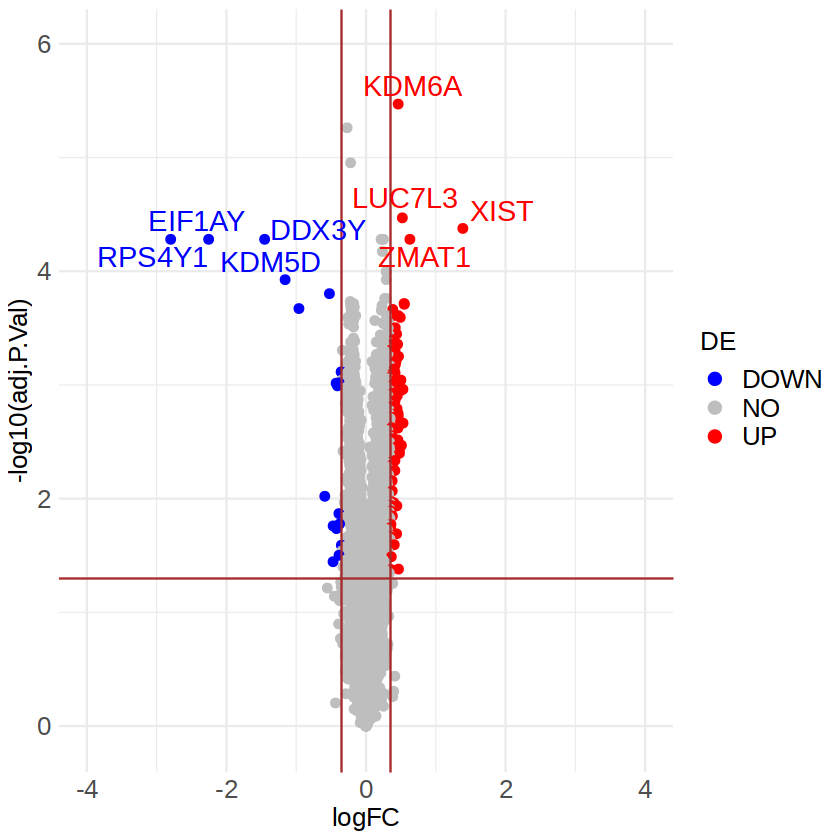

In [13]:
#### plot volcano

fold_cutoff = 0.35

limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA

limma_result_fit$delabel[limma_result_fit$diffexpressed != "NO"] <- limma_result_fit$gene_symbol[limma_result_fit$diffexpressed != "NO"]

ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-4, 4) +ylim(-0.1,6) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=6,max.overlaps=10)
        
ggsave("figs/RP_2c.png",dpi=600)    


In [33]:
### get the DE Genes

limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ] 

In [34]:
limma_DE

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
KDM6A,0.4611196,4.687607,6.749029,1.691020e-10,3.387452e-06,13.408177,KDM6A,UP,KDM6A
LUC7L3,0.5208104,7.207846,6.066253,6.773002e-09,3.391919e-05,9.969672,LUC7L3,UP,LUC7L3
XIST,1.3877096,3.468701,5.982172,1.049022e-08,4.202800e-05,9.562716,XIST,UP,XIST
EIF1AY,-2.2548205,5.631488,-5.856626,2.001333e-08,5.239845e-05,8.962209,EIF1AY,DOWN,EIF1AY
RPS4Y1,-2.7985347,7.657289,-5.826206,2.337303e-08,5.239845e-05,8.818010,RPS4Y1,DOWN,RPS4Y1
ZMAT1,0.6288363,3.832726,5.816016,2.461737e-08,5.239845e-05,8.769819,ZMAT1,UP,ZMAT1
DDX3Y,-1.4523937,4.538040,-5.799264,2.680498e-08,5.239845e-05,8.690727,DDX3Y,DOWN,DDX3Y
KDM5D,-1.1588661,4.610383,-5.546896,9.477763e-08,1.186616e-04,7.518494,KDM5D,DOWN,KDM5D
TTTY10,-0.5238733,3.611383,-5.476842,1.336814e-07,1.575239e-04,7.199648,TTTY10,DOWN,TTTY10


In [35]:
limma_DE$delabel

[1] "KDM6A"      "LUC7L3"     "XIST"       "EIF1AY"     "RPS4Y1"    
  [6] "ZMAT1"      "DDX3Y"      "KDM5D"      "TTTY10"     "CHORDC1"   
 [11] "CD46"       "PRKY"       "ATP10D"     "CMAHP"      "CBWD3"     
 [16] "ZNF117"     "PTPN12"     "CSGALNACT2" "PRPF38B"    "FAS"       
 [21] "PNISR"      "FAM126B"    "KRCC1"      "MYBL1"      "EDEM3"     
 [26] "ODF2L"      "ECHDC1"     "ITGB1"      "RBM7"       "JMJD1C"    
 [31] "N4BP2L2"    "FGFR1OP2"   "UBR3"       "USP9Y"      "CEP170"    
 [36] "HIAT1"      "CAPN7"      "CLINT1"     "MOSPD2"     "SGMS1"     
 [41] "COL4A3BP"   "PGLYRP1"    "PAG1"       "PRKX"       "CAMP"      
 [46] "UBR5"       "RNF145"     "SLC35F5"    "POLI"       "EIF1AX"    
 [51] "PLAGL1"     "C1ORF27"    "PGRMC2"     "PAPOLG"     "PTP4A1"    
 [56] "ZNF382"     "KIAA1468"   "CDC37L1"    "FAR1"       "TMF1"      
 [61] "SEC23A"     "MYO5A"      "TSPAN13"    "ZNF84"      "ZBTB1"     
 [66] "FBXL3"      "ZNRF2"      "RAB28"      "ARMCX3"     "SMC4"      
 [71] "CASP8AP2"   "VCPIP1"     "ZNF267"     "GLCCI1"     "SACS"      
 [76] "LYZ"        "TUBE1"      "KLHL28"     "NFXL1"      "MIB1"      
 [81] "SUB1"       "PKN2"       "TMEM55A"    "ZBTB21"     "SOAT1"     
 [86] "TXLNG2P"    "TMEM170B"   "CXCL5.1"    "TRIM51EP"   "ZNF92"     
 [91] "CNTNAP3B.1" "PDE3B"      "GBP3"       "TRPC1"      "KLC3"      
 [96] "USP53"      "PRSS33"     "C4ORF32"    "CCL23"      "CFH.1"     
[101] "HBQ1"       "TFEC"       "FIGNL1"     "CLVS1"      "GSTT1"     
[106] "LTF"        "CFH"        "HBD"        "CPA3"       "C2ORF69"

In [36]:
write.csv(limma_DE,"DE_results/RP_limmaDE_EMCI.csv")

In [17]:
top10 <- topTable(fit2,  coef=1, n=10,sort.by="p")
top10

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LUC7L3,0.6153943,7.207846,6.963423,4.568928e-11,9.152476e-07,14.694880
KDM6A,0.4644483,4.687607,6.755762,1.484915e-10,1.035676e-06,13.586568
ZMAT1,0.7844973,3.832726,6.748015,1.551032e-10,1.035676e-06,13.545619
DDX5,0.2709642,10.356816,6.248745,2.409721e-09,9.482085e-06,10.969573
UROS,-0.2309937,6.124095,-6.247802,2.421935e-09,9.482085e-06,10.964831
HK3,-0.3504250,6.722761,-6.218058,2.840081e-09,9.482085e-06,10.815446
F8A2,-0.2045573,4.760632,-6.129718,4.544948e-09,1.285633e-05,10.374567
CD53,0.2323336,9.869100,6.106676,5.134316e-09,1.285633e-05,10.260270
XIST,1.4182019,3.468701,6.074115,6.096700e-09,1.356990e-05,10.099249


In [1]:
limma_DE = read.csv("DE_results/RP_limmaDE_EMCI.csv")

In [2]:
limma_DE$log

X,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol,diffexpressed,delabel
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
KDM6A,0.4611196,4.687607,6.749029,1.691020e-10,3.387452e-06,13.408177,KDM6A,UP,KDM6A
LUC7L3,0.5208104,7.207846,6.066253,6.773002e-09,3.391919e-05,9.969672,LUC7L3,UP,LUC7L3
XIST,1.3877096,3.468701,5.982172,1.049022e-08,4.202800e-05,9.562716,XIST,UP,XIST
EIF1AY,-2.2548205,5.631488,-5.856626,2.001333e-08,5.239845e-05,8.962209,EIF1AY,DOWN,EIF1AY
RPS4Y1,-2.7985347,7.657289,-5.826206,2.337303e-08,5.239845e-05,8.818010,RPS4Y1,DOWN,RPS4Y1
ZMAT1,0.6288363,3.832726,5.816016,2.461737e-08,5.239845e-05,8.769819,ZMAT1,UP,ZMAT1
DDX3Y,-1.4523937,4.538040,-5.799264,2.680498e-08,5.239845e-05,8.690727,DDX3Y,DOWN,DDX3Y
KDM5D,-1.1588661,4.610383,-5.546896,9.477763e-08,1.186616e-04,7.518494,KDM5D,DOWN,KDM5D
TTTY10,-0.5238733,3.611383,-5.476842,1.336814e-07,1.575239e-04,7.199648,TTTY10,DOWN,TTTY10
